## Fashion-MNIST Image Classification Project

## **Set 1 Construct a forward neural network**

With this set of tasks, we are going to build a feedforward neural network for a classification task. We will train the model on the Fashion MNIST dataset (https://github.com/zalandoresearch/fashion-mnist).

### Understanding the data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

C:\Users\Hp\anaconda3\lib\site-packages\requests\__init__.py:102: RequestsDependencyWarning: urllib3 (1.26.18) or chardet (5.2.0)/charset_normalizer (2.0.12) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({})/charset_normalizer ({}) doesn't match a supported "


In [2]:
# Load the Fashion-MNIST dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [1]:
#Display 5 Training Examples from Each Class
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [4]:
def display_examples(images, labels, class_names, num_examples=5):
    fig, axes = plt.subplots(len(class_names), num_examples, figsize=(10, 10))
    fig.subplots_adjust(hspace=0.5)
    
    for i, class_name in enumerate(class_names):
        class_indices = np.where(labels == i)[0][:num_examples]
        for j in range(num_examples):
            axes[i, j].imshow(images[class_indices[j]], cmap='gray')
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(class_name)

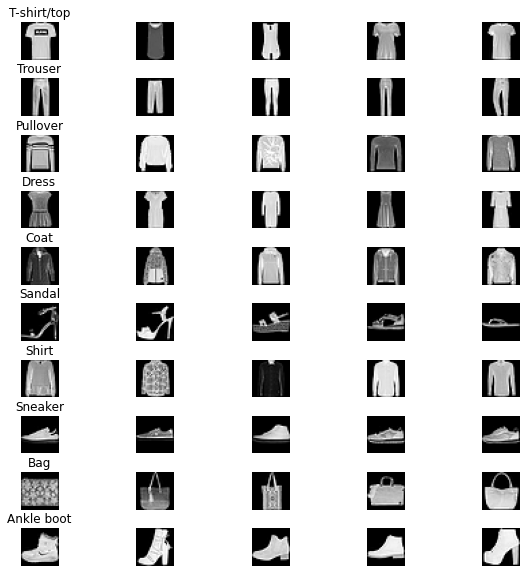

In [5]:
display_examples(train_images, train_labels, class_names)

The Fashion-MNIST dataset has 60,000 training images and 10,000 test images. After splitting the training data, we use 
48,000 images for training and 12,000 for validation.

There are 10 classes in the data set

In [6]:
#Step 3: Prepare the Data for Training a Neural Network
# Normalize the images
train_images = train_images / 255.0
test_images = test_images / 255.0

In [7]:
# Reshape images
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

In [8]:
# Split the training data into training and validation sets
from sklearn.model_selection import train_test_split

train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.2, 
                                                                      random_state=42)

# Pre Processing Steps

## Normalization
Normalizing the images helps in making the model training more stable and speeds up convergence by ensuring that the 
inputs are on a similar scale. It also reduces the chances of issues like exploding or vanishing gradients.


## Reshape the Images
The images are reshaped to include a channel dimension because convolutional neural networks (CNNs) require a 4D tensor 
as input. Even though we are working with fully connected layers, the input format still needs to conform to the expected 
dimensions.

## Split the Data into Training and Validation Sets
Splitting the data into training and validation sets allows us to monitor the model's performance on unseen data during 
training. This helps in assessing generalization and avoiding overfitting.

### Setting up a model for training

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import plot_model

In [10]:
# Define the model
model = Sequential([
    Flatten(input_shape=(28, 28)),  # Input layer: reshape (28, 28) to (784,)
    Dense(128, activation='relu'),  # First hidden layer
    Dense(64, activation='relu'),   # Second hidden layer
    Dense(32, activation='relu'),   # Third hidden layer
    Dense(10, activation='softmax') # Output layer
])

In [11]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [16]:
# Display the model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 10)                330       
                                                                 
Total params: 111,146
Trainable params: 111,146
Non-trainable params: 0
_________________________________________________________________


### Fitting the model

In [17]:
import matplotlib.pyplot as plt

# Fit the model
history = model.fit(train_images, train_labels, 
                    epochs=20, 
                    batch_size=32, 
                    validation_data=(val_images, val_labels))

Epoch 1/20
1500/1500 [==============================] - 7s 4ms/step - loss: 0.5375 - accuracy: 0.8100 - val_loss: 0.4361 - val_accuracy: 0.8447
Epoch 2/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3837 - accuracy: 0.8571 - val_loss: 0.3818 - val_accuracy: 0.8613
Epoch 3/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3462 - accuracy: 0.8729 - val_loss: 0.3681 - val_accuracy: 0.8649
Epoch 4/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3239 - accuracy: 0.8802 - val_loss: 0.3498 - val_accuracy: 0.8763
Epoch 5/20
1500/1500 [==============================] - 7s 4ms/step - loss: 0.3020 - accuracy: 0.8882 - val_loss: 0.3360 - val_accuracy: 0.8772
Epoch 6/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.2870 - accuracy: 0.8923 - val_loss: 0.3346 - val_accuracy: 0.8797
Epoch 7/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.2764 - accuracy: 0.8970 - val_loss: 0.3162 - val_accuracy:

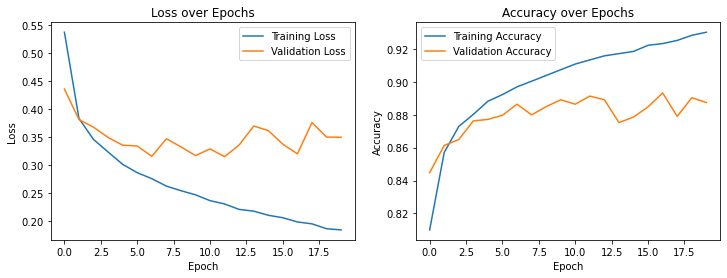

In [18]:
# Plot training & validation loss and accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [19]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

313/313 [==============================] - 1s 2ms/step - loss: 0.3783 - accuracy: 0.8824
Test Loss: 0.3783
Test Accuracy: 0.8824


## **Improve the model**

In [20]:
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
import datetime

In [21]:
# Define TensorBoard callback
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [22]:
# Fit the model with TensorBoard callback
history = model.fit(
    train_images, 
    train_labels, 
    epochs=20, 
    batch_size=32, 
    validation_data=(val_images, val_labels),
    callbacks=[tensorboard_callback, early_stopping]
)

Epoch 1/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.1801 - accuracy: 0.9318 - val_loss: 0.3663 - val_accuracy: 0.8876
Epoch 2/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.1756 - accuracy: 0.9331 - val_loss: 0.3469 - val_accuracy: 0.8920
Epoch 3/20
1500/1500 [==============================] - 7s 4ms/step - loss: 0.1694 - accuracy: 0.9352 - val_loss: 0.3661 - val_accuracy: 0.8907
Epoch 4/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.1683 - accuracy: 0.9363 - val_loss: 0.3744 - val_accuracy: 0.8862
Epoch 5/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.1652 - accuracy: 0.9372 - val_loss: 0.3600 - val_accuracy: 0.8901
Epoch 6/20
1500/1500 [==============================] - 7s 4ms/step - loss: 0.1593 - accuracy: 0.9388 - val_loss: 0.3832 - val_accuracy: 0.8916
Epoch 7/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.1554 - accuracy: 0.9408 - val_loss: 0.4280 - val_accuracy:

## Epoch Loss:
The graph shows the loss on both training (likely the darker line) and validation data (likely the lighter line) over 
epochs. The training loss is decreasing steadily, which indicates that the model is learning and fitting the training data
better over time. The validation loss, however, is not showing a clear decreasing trend. It fluctuates and even increases 
after certain epochs, suggesting potential overfitting.

## Epoch Accuracy:
The graph displays the accuracy on both training (likely the darker line) and validation data (likely the lighter line) over
epochs. The training accuracy is improving, indicating the model's performance on the training set is getting better. The
validation accuracy seems relatively flat with some fluctuations, indicating that the model's performance on unseen data is
not improving significantly and may be a sign of overfitting.

In [23]:
from tensorflow.keras.layers import Dropout, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
import datetime

# Model with Dropout
dropout_model = Sequential([
    Flatten(input_shape=(28, 28)),  # Input layer: reshape (28, 28) to (784,)
    Dense(128, activation='relu'),  # First hidden layer
    Dropout(0.5),
    Dense(64, activation='relu'),   # Second hidden layer
    Dropout(0.5),
    Dense(32, activation='relu'),   # Third hidden layer
    Dropout(0.5),
    Dense(10, activation='softmax')
])

dropout_model.compile(optimizer=Adam(learning_rate=0.001),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Fit the model with Dropout
dropout_history = dropout_model.fit(train_images, train_labels, epochs=20, batch_size=32,
                                    validation_data=(val_images, val_labels),
                                    callbacks=[tensorboard_callback, early_stopping])

Epoch 1/20
1500/1500 [==============================] - 9s 5ms/step - loss: 1.2057 - accuracy: 0.5471 - val_loss: 0.6408 - val_accuracy: 0.7586
Epoch 2/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.8059 - accuracy: 0.6923 - val_loss: 0.5921 - val_accuracy: 0.7657
Epoch 3/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.7469 - accuracy: 0.7148 - val_loss: 0.5596 - val_accuracy: 0.7852
Epoch 4/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.7145 - accuracy: 0.7315 - val_loss: 0.5567 - val_accuracy: 0.7692
Epoch 5/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.6934 - accuracy: 0.7407 - val_loss: 0.5189 - val_accuracy: 0.8018
Epoch 6/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.6757 - accuracy: 0.7507 - val_loss: 0.5168 - val_accuracy: 0.7992
Epoch 7/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.6657 - accuracy: 0.7562 - val_loss: 0.5032 - val_accuracy:

In [24]:
# Model with Batch Normalization
from tensorflow.keras.layers import BatchNormalization
    
batchnorm_model = Sequential([
    Flatten(input_shape=(28, 28)),  # Input layer: reshape (28, 28) to (784,)
    Dense(128, activation='relu'),  # First hidden layer
    BatchNormalization(),
    Dense(64, activation='relu'),   # Second hidden layer
    BatchNormalization(),
    Dense(32, activation='relu'),   # Third hidden layer
    BatchNormalization(),
    Dense(10, activation='softmax')
])

batchnorm_model.compile(optimizer=Adam(learning_rate=0.001),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Fit the model with Batch Normalization
batchnorm_history = batchnorm_model.fit(train_images, train_labels, epochs=20, batch_size=32,
                                        validation_data=(val_images, val_labels),
                                        callbacks=[tensorboard_callback, early_stopping])

Epoch 1/20
1500/1500 [==============================] - 11s 5ms/step - loss: 0.5406 - accuracy: 0.8114 - val_loss: 0.4743 - val_accuracy: 0.8253
Epoch 2/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.4088 - accuracy: 0.8505 - val_loss: 0.4227 - val_accuracy: 0.8429
Epoch 3/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.3765 - accuracy: 0.8623 - val_loss: 0.3817 - val_accuracy: 0.8632
Epoch 4/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.3531 - accuracy: 0.8721 - val_loss: 0.3652 - val_accuracy: 0.8678
Epoch 5/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.3348 - accuracy: 0.8779 - val_loss: 0.3639 - val_accuracy: 0.8658
Epoch 6/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.3265 - accuracy: 0.8799 - val_loss: 0.3448 - val_accuracy: 0.8786
Epoch 7/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.3095 - accuracy: 0.8843 - val_loss: 0.4237 - val_accuracy

In [25]:
from tensorflow.keras.regularizers import l2

# Model with L2 Regularization
l2_model = Sequential([
    Flatten(input_shape=(28, 28)),  # Input layer: reshape (28, 28) to (784,)
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),  # First hidden layer
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),   # Second hidden layer
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),   # Third hidden layer
    Dense(10, activation='softmax')
])

l2_model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# Fit the model with L2 Regularization
l2_history = l2_model.fit(train_images, train_labels, epochs=20, batch_size=32,
                          validation_data=(val_images, val_labels),
                          callbacks=[tensorboard_callback, early_stopping])

Epoch 1/20
1500/1500 [==============================] - 9s 5ms/step - loss: 1.2482 - accuracy: 0.7753 - val_loss: 0.9301 - val_accuracy: 0.7841
Epoch 2/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.8433 - accuracy: 0.7992 - val_loss: 0.7996 - val_accuracy: 0.8040
Epoch 3/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.7671 - accuracy: 0.8090 - val_loss: 0.7250 - val_accuracy: 0.8217
Epoch 4/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.7271 - accuracy: 0.8162 - val_loss: 0.7243 - val_accuracy: 0.8158
Epoch 5/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.6998 - accuracy: 0.8212 - val_loss: 0.6829 - val_accuracy: 0.8202
Epoch 6/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.6746 - accuracy: 0.8260 - val_loss: 0.6630 - val_accuracy: 0.8287
Epoch 7/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.6612 - accuracy: 0.8270 - val_loss: 0.6617 - val_accuracy:

In [26]:
from tensorflow.keras.callbacks import LearningRateScheduler

# Define the learning rate schedule
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * 0.1

lr_scheduler = LearningRateScheduler(scheduler)

In [27]:
# Model with Learning Rate Scheduling
lrs_model = Sequential([
    Flatten(input_shape=(28, 28)),  # Input layer: reshape (28, 28) to (784,)
    Dense(128, activation='relu'),  # First hidden layer
    Dense(64, activation='relu'),   # Second hidden layer
    Dense(32, activation='relu'),   # Third hidden layer
    Dense(10, activation='softmax')
])

lrs_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Fit the model with Learning Rate Scheduling
lrs_history = lrs_model.fit(train_images, train_labels, epochs=20, batch_size=32,
                            validation_data=(val_images, val_labels),
                            callbacks=[tensorboard_callback, early_stopping, lr_scheduler])

Epoch 1/20
1500/1500 [==============================] - 8s 4ms/step - loss: 0.5188 - accuracy: 0.8148 - val_loss: 0.4285 - val_accuracy: 0.8421 - lr: 0.0010
Epoch 2/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3874 - accuracy: 0.8577 - val_loss: 0.3626 - val_accuracy: 0.8668 - lr: 0.0010
Epoch 3/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3471 - accuracy: 0.8737 - val_loss: 0.3409 - val_accuracy: 0.8764 - lr: 0.0010
Epoch 4/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3228 - accuracy: 0.8808 - val_loss: 0.3591 - val_accuracy: 0.8703 - lr: 0.0010
Epoch 5/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3035 - accuracy: 0.8886 - val_loss: 0.3616 - val_accuracy: 0.8658 - lr: 0.0010
Epoch 6/20
1500/1500 [==============================] - 6s 4ms/step - loss: 0.2879 - accuracy: 0.8934 - val_loss: 0.3358 - val_accuracy: 0.8767 - lr: 0.0010
Epoch 7/20
1500/1500 [==============================] - 6s

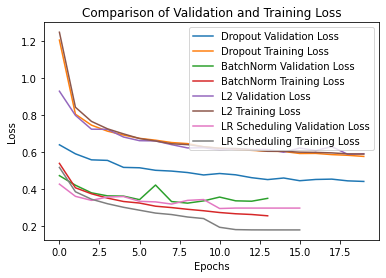

In [28]:
import matplotlib.pyplot as plt

def plot_history(histories, titles):
    for history, title in zip(histories, titles):
        plt.plot(history.history['val_loss'], label=f'{title} Validation Loss')
        plt.plot(history.history['loss'], label=f'{title} Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Comparison of Validation and Training Loss')
    plt.show()

plot_history([dropout_history, batchnorm_history, l2_history, lrs_history],
             ['Dropout', 'BatchNorm', 'L2', 'LR Scheduling'])

### Dropout:
The Dropout model shows a higher validation loss compared to the training loss, indicating some level of overfitting. 
However, the training loss decreases steadily, suggesting that the model is learning.

### Batch Normalization:
The Batch Normalization model has a more stable and lower validation loss compared to the training loss, indicating 
effective regularization and reduced overfitting. This suggests that batch normalization helps the model generalize better
on unseen data.

### L2 Regularization:
The L2 Regularization model's validation and training losses are closer to each other, which is a good sign of balanced 
learning. The losses are relatively low and stable, indicating that L2 regularization effectively mitigates overfitting.

### Learning Rate Scheduling:
The Learning Rate Scheduling model shows a steadily decreasing validation loss along with the training loss, suggesting 
that the learning rate schedule helps the model converge more smoothly. This is particularly evident after the initial 
epochs where the learning rate might have been adjusted.

## Overall Observations:

### Overfitting: 
The Dropout model shows signs of overfitting due to the gap between training and validation loss.

### Underfitting: 
None of the models appear to underfit significantly, as all models show decreasing training and validation 
losses.

### Effectiveness: 
Batch Normalization, L2 Regularization, and Learning Rate Scheduling seem to be effective in reducing 
overfitting and improving model generalization, with Batch Normalization showing the most stable performance.

### Conclusion:
Batch Normalization and L2 Regularization appear to be the most effective regularization techniques in this case, as 
indicated by their stable and lower validation losses. Learning Rate Scheduling also helps in achieving a smooth 
convergence. Based on these observations, combining Batch Normalization with L2 Regularization and Learning Rate 
Scheduling could potentially yield even better results.

## **Analyse the learned representations**

In [62]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, LambdaCallback

In [63]:
# Create a directory to save the checkpoints
checkpoint_dir = './checkpoints'
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

In [64]:
# Define file paths for the checkpoints
checkpoint_initial = os.path.join(checkpoint_dir, 'model_initial.h5')
checkpoint_midway = os.path.join(checkpoint_dir, 'model_midway.h5')
checkpoint_end = os.path.join(checkpoint_dir, 'model_end.h5')

In [65]:
# Callback to save the initial weights
save_initial_callback = LambdaCallback(on_epoch_end=lambda epoch, logs: lrs_model.save_weights(checkpoint_initial) 
                                       if epoch == 0 else None)

# Callback to save the midway weights
save_midway_callback = LambdaCallback(on_epoch_end=lambda epoch, logs: lrs_model.save_weights(checkpoint_midway) 
                                      if epoch == int(20/2) else None)

# Callback to save the final weights
save_end_callback = ModelCheckpoint(filepath=checkpoint_end, save_best_only=False, save_weights_only=True, verbose=1)

In [66]:
# Fit the model with Learning Rate Scheduling and save checkpoints
lrs_history = lrs_model.fit(train_images, train_labels, epochs=20, batch_size=32,
                            validation_data=(val_images, val_labels),
                            callbacks=[tensorboard_callback, early_stopping, lr_scheduler, save_initial_callback, 
                                       save_midway_callback, save_end_callback])

Epoch 1/20
1489/1500 [============================>.] - ETA: 0s - loss: 0.1845 - accuracy: 0.9299
Epoch 1: saving model to ./checkpoints\model_end.h5
1500/1500 [==============================] - 7s 4ms/step - loss: 0.1842 - accuracy: 0.9299 - val_loss: 0.2970 - val_accuracy: 0.8978 - lr: 1.0000e-14
Epoch 2/20
1496/1500 [============================>.] - ETA: 0s - loss: 0.1843 - accuracy: 0.9299
Epoch 2: saving model to ./checkpoints\model_end.h5
1500/1500 [==============================] - 6s 4ms/step - loss: 0.1842 - accuracy: 0.9299 - val_loss: 0.2970 - val_accuracy: 0.8978 - lr: 1.0000e-14
Epoch 3/20
1492/1500 [============================>.] - ETA: 0s - loss: 0.1842 - accuracy: 0.9300
Epoch 3: saving model to ./checkpoints\model_end.h5
1500/1500 [==============================] - 7s 4ms/step - loss: 0.1842 - accuracy: 0.9299 - val_loss: 0.2970 - val_accuracy: 0.8978 - lr: 1.0000e-14
Epoch 4/20
1489/1500 [============================>.] - ETA: 0s - loss: 0.1844 - accuracy: 0.9299
Ep

In [67]:
def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),  # Input layer: reshape (28, 28) to (784,)
        Dense(128, activation='relu'),  # First hidden layer
        Dense(64, activation='relu'),   # Second hidden layer
        Dense(32, activation='relu'),   # Third hidden layer
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [68]:
# Load the model checkpoints for different training stages
model_beginning = create_model()
model_beginning.load_weights(checkpoint_initial)

model_midway = create_model()
model_midway.load_weights(checkpoint_midway)

model_end = create_model()
model_end.load_weights(checkpoint_end)

In [69]:
import numpy as np

# Select a subset of the training data
subset_indices = np.random.choice(len(train_images), size=500, replace=False)
subset_images = train_images[subset_indices]
subset_labels = train_labels[subset_indices]

In [70]:
from tensorflow.keras.models import Model

def get_layer_outputs(model, data):
    layer_outputs = [layer.output for layer in model.layers[1:]]
    intermediate_model = Model(inputs=model.input, outputs=layer_outputs)
    return intermediate_model.predict(data)

# Get embeddings for each stage of training
embeddings_beginning = get_layer_outputs(model_beginning, subset_images)
embeddings_midway = get_layer_outputs(model_midway, subset_images)
embeddings_end = get_layer_outputs(model_end, subset_images)

16/16 [==============================] - 0s 3ms/step


In [74]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

def plot_embeddings(embeddings, labels, title):
    reducer = umap.UMAP(n_components=2, random_state=42)
    embeddings_2d = reducer.fit_transform(embeddings)
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='Spectral', s=5)
    plt.colorbar(scatter)
    plt.title(title)
    plt.show()

C:\Users\Hp\anaconda3\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


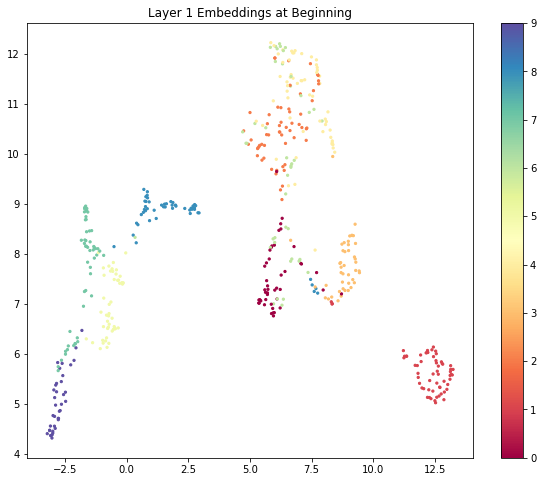

C:\Users\Hp\anaconda3\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


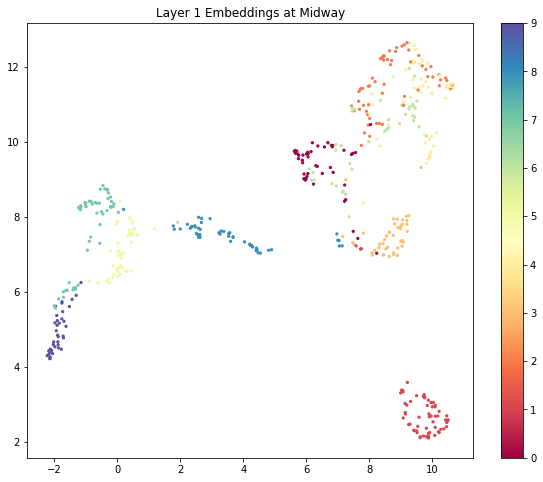

C:\Users\Hp\anaconda3\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


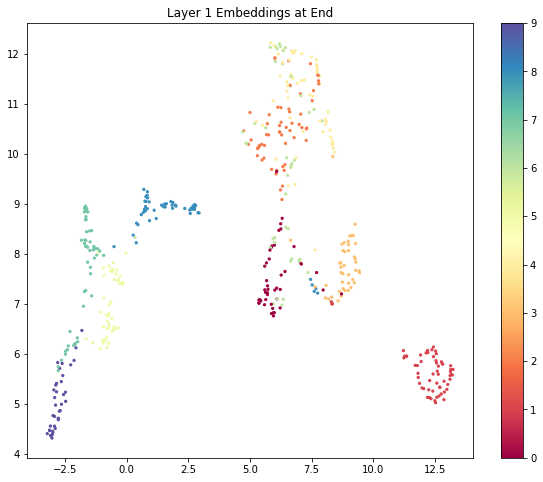

C:\Users\Hp\anaconda3\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


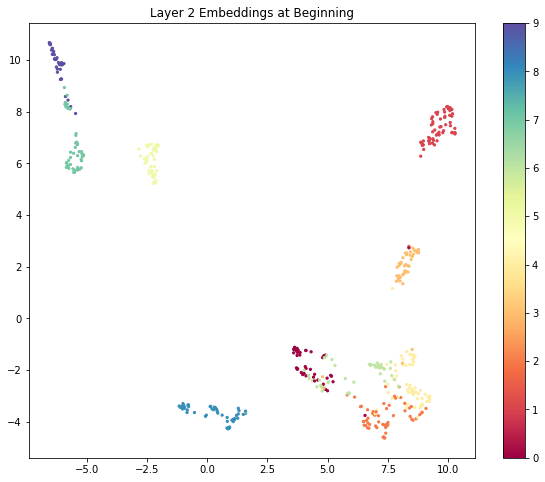

C:\Users\Hp\anaconda3\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


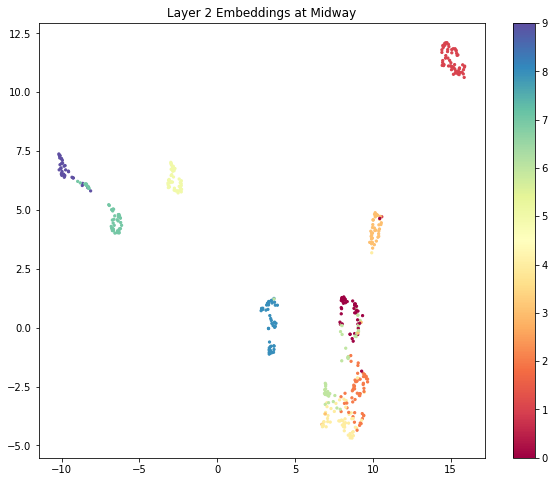

C:\Users\Hp\anaconda3\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


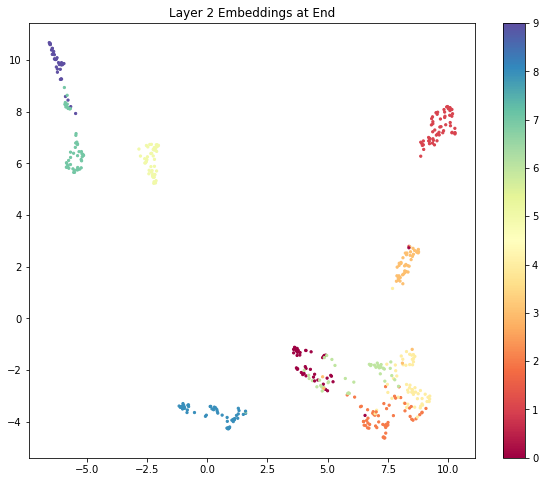

C:\Users\Hp\anaconda3\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


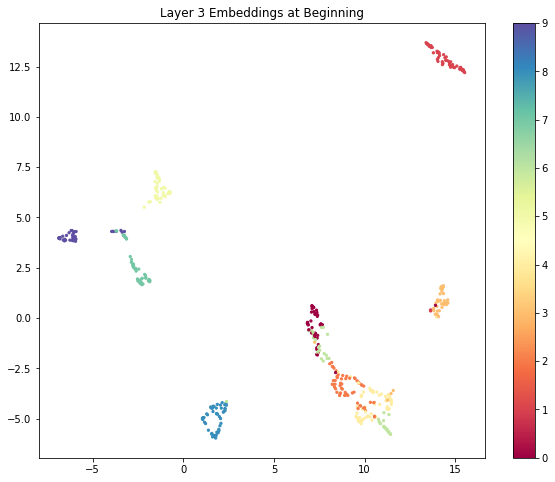

C:\Users\Hp\anaconda3\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


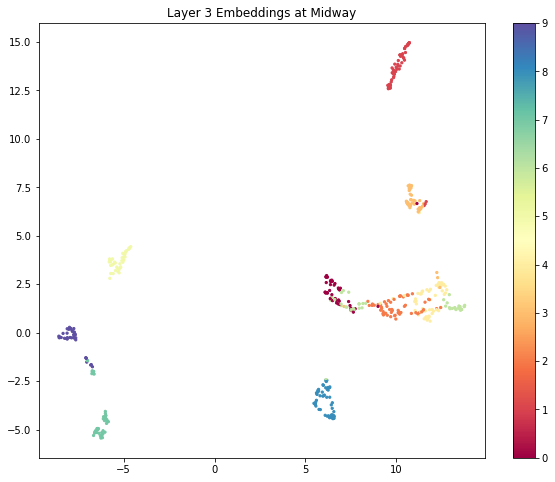

C:\Users\Hp\anaconda3\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


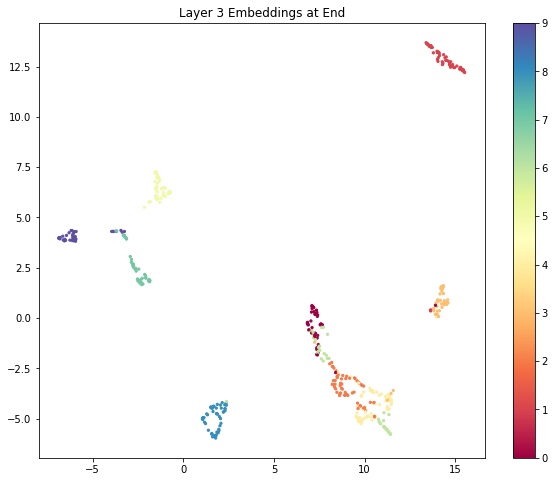

C:\Users\Hp\anaconda3\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


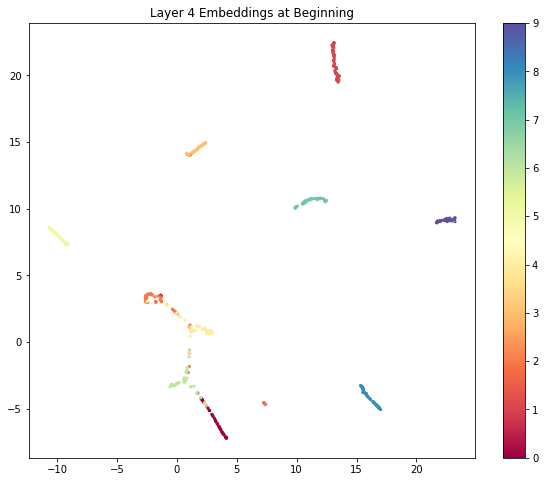

C:\Users\Hp\anaconda3\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


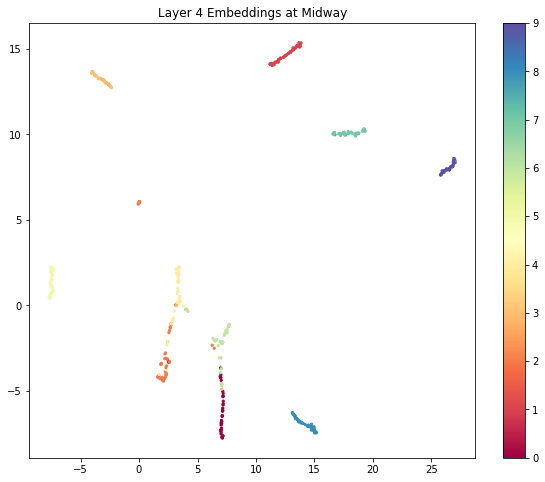

C:\Users\Hp\anaconda3\lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


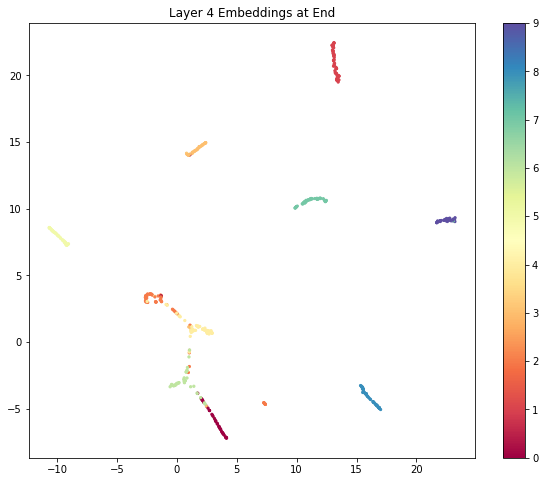

In [75]:
# Plot embeddings for each layer of the model at different training stages
for i, layer in enumerate(lrs_model.layers[1:], 1):
    plot_embeddings(embeddings_beginning[i-1], subset_labels, f'Layer {i} Embeddings at Beginning')
    plot_embeddings(embeddings_midway[i-1], subset_labels, f'Layer {i} Embeddings at Midway')
    plot_embeddings(embeddings_end[i-1], subset_labels, f'Layer {i} Embeddings at End')

## Clear Separation Between Classes

### Layer 1: 
The first layer shows a dispersed structure, with the embeddings spread across the space. There is some grouping
based on the color, which corresponds to different classes, but the separation is not very clear. The embeddings are still 
relatively entangled, indicating that the network is in the early stages of learning meaningful features.

### Layer 2: 
In the second layer, there is more visible clustering. The embeddings are starting to form distinct groups, with 
each cluster corresponding to a different class. However, there is still some overlap between the classes, indicating that 
the network is not yet fully capable of separating them.

### Layer 3: 
By the third layer, the embeddings show even more distinct clustering. The separation between classes becomes 
clearer, with each class forming a more compact cluster. This suggests that the network is beginning to learn 
representations that better differentiate between the classes.
'''

## Changes in Separation and Clustering Across Layers

### Layer 1 to Layer 2: 
As we move from Layer 1 to Layer 2, there is a noticeable improvement in the separation of classes. 
The clusters become tighter and more distinct, indicating that the network is starting to capture more meaningful features.

### Layer 2 to Layer 3: 
The transition from Layer 2 to Layer 3 further enhances the separation, with the embeddings becoming 
even more compact and well-separated. This progression suggests that the deeper layers of the network are more effective 
at learning discriminative features that separate the classes.

### Observations on the Embeddings at the Beginning of Training

## Layer 1: 
At the beginning, the embeddings are relatively dispersed, with classes not well-separated. This is typical at the
start of training, as the network has not yet learned to extract useful features.

## Layer 2:
There is an improvement in clustering, showing that the network is starting to learn useful features that can 
separate the classes.

## Layer 3:
The embeddings show even clearer class separation, indicating that the network is beginning to specialize and 
learn more refined features.

## Changes in Distribution or Structure of the Embeddings

The embeddings become more structured and clustered as we move from Layer 1 to Layer 3. This change reflects the network's 
increasing ability to learn and represent features that distinguish the different classes.

## Layers with Less Discriminative Embeddings
 
### Layer 1: 
The embeddings in the first layer are the least discriminative, as expected at the beginning of training. This 
layer is likely still learning to capture basic features.

### Layer 3: 
The embeddings in Layer 3 are the most discriminative at the beginning of training, as the network has started to 
learn more specific features that separate the classes effectively.